In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [15]:
BASE_DIR = Path.cwd().parent

PROCESSED_DATA_PATH = (
    BASE_DIR
    / "Data"
    / "Processed"
    / "diabetic_data_processed.csv"
)

print("Project directory:")
print(BASE_DIR)

print("\nProcessed data path:")
print(PROCESSED_DATA_PATH)

Project directory:
c:\Users\Sai\Documents\HealthSense_AI

Processed data path:
c:\Users\Sai\Documents\HealthSense_AI\Data\Processed\diabetic_data_processed.csv


In [16]:
df = pd.read_csv(
    PROCESSED_DATA_PATH
)

print(
    "Dataset loaded successfully."
)

print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)

Dataset loaded successfully.
Rows: 101766
Columns: 50


In [17]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted',
 'max_glu_serum_available',
 'A1Cresult_available']

In [18]:
print(
    "Readmission target distribution:"
)

print(
    df["readmitted"].value_counts()
)

print(
    "\nReadmission percentage:"
)

print(
    df["readmitted"]
    .value_counts(
        normalize=True
    )
    * 100
)

Readmission target distribution:
readmitted
0    54864
1    46902
Name: count, dtype: int64

Readmission percentage:
readmitted
0    53.911916
1    46.088084
Name: proportion, dtype: float64


In [19]:
print(
    "Total encounters:",
    len(df)
)

print(
    "Unique patients:",
    df["patient_nbr"].nunique()
)

print(
    "Repeated patient IDs:",
    df["patient_nbr"].duplicated().sum()
)

Total encounters: 101766
Unique patients: 71518
Repeated patient IDs: 30248


In [20]:
df["total_previous_visits"] = (
    df["number_inpatient"]
    + df["number_emergency"]
    + df["number_outpatient"]
)

df[
    [
        "number_inpatient",
        "number_emergency",
        "number_outpatient",
        "total_previous_visits"
    ]
].head()

,number_inpatient,number_emergency,number_outpatient,total_previous_visits
0,0,0,0,0
1,0,0,0,0
2,1,0,2,3
3,0,0,0,0
4,0,0,0,0


In [21]:
df["high_utilization_patient"] = (
    df["total_previous_visits"] >= 3
).astype(int)

df[
    "high_utilization_patient"
].value_counts()

df[
    [
        "total_previous_visits",
        "high_utilization_patient"
    ]
].head(20)

,total_previous_visits,high_utilization_patient
0,0,0
1,0,0
2,3,1
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [22]:
df["high_risk_utilization"] = (
    (
        df["number_inpatient"] >= 2
    )
    |
    (
        df["number_emergency"] >= 2
    )
    |
    (
        df["number_outpatient"] >= 3
    )
).astype(int)



df[
    "high_risk_utilization"
].value_counts()

high_risk_utilization
0    82054
1    19712
Name: count, dtype: int64

In [23]:
print(
    "Readmission rate by high utilization:"
)

print(
    df.groupby(
        "high_utilization_patient"
    )[
        "readmitted"
    ].mean()
    * 100
)


print(
    "\nReadmission rate by high-risk utilization:"
)

print(
    df.groupby(
        "high_risk_utilization"
    )[
        "readmitted"
    ].mean()
    * 100
)

Readmission rate by high utilization:
high_utilization_patient
0    42.110659
1    67.511767
Name: readmitted, dtype: float64

Readmission rate by high-risk utilization:
high_risk_utilization
0    41.23504
1    66.28957
Name: readmitted, dtype: float64


In [24]:
df["medication_complexity"] = pd.cut(
    df["num_medications"],
    bins=[
        -1,
        5,
        10,
        20,
        30,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very_High",
        "Extreme"
    ]
)


df[
    "medication_complexity"
].value_counts()

medication_complexity
High         52025
Moderate     20795
Very_High    18643
Extreme       5237
Low           5066
Name: count, dtype: int64

In [25]:
df["high_medication_burden"] = (
    df["num_medications"] >= 15
).astype(int)

df[
    "high_medication_burden"
].value_counts()

df.groupby(
    "high_medication_burden"
)[
    "readmitted"
].mean() * 100

high_medication_burden
0    42.854832
1    49.144572
Name: readmitted, dtype: float64

In [26]:
df["hospital_stay_category"] = pd.cut(
    df["time_in_hospital"],
    bins=[
        0,
        3,
        7,
        14,
        np.inf
    ],
    labels=[
        "Short",
        "Medium",
        "Long",
        "Very_Long"
    ]
)


df[
    "hospital_stay_category"
].value_counts()


df.groupby(
    "hospital_stay_category",
    observed=True
)[
    "readmitted"
].mean() * 100

hospital_stay_category
Short     43.187363
Medium    48.465994
Long      49.620667
Name: readmitted, dtype: float64

In [27]:
def categorize_diagnosis(code):
    """
    Convert ICD-9 diagnosis codes
    into broad clinical categories.
    """

    if pd.isna(code):
        return "Unknown"

    try:
        code = str(code)

        if code.startswith("V"):
            return "Supplementary"

        if code.startswith("E"):
            return "Injury"

        code = float(code)

        if 140 <= code <= 239:
            return "Neoplasms"

        elif 250 <= code < 251:
            return "Diabetes"

        elif 290 <= code <= 319:
            return "Mental"

        elif 320 <= code <= 389:
            return "Nervous_System"

        elif 390 <= code <= 459:
            return "Circulatory"

        elif 460 <= code <= 519:
            return "Respiratory"

        elif 520 <= code <= 579:
            return "Digestive"

        elif 580 <= code <= 629:
            return "Genitourinary"

        elif 630 <= code <= 679:
            return "Pregnancy"

        elif 680 <= code <= 709:
            return "Skin"

        elif 710 <= code <= 739:
            return "Musculoskeletal"

        elif 740 <= code <= 759:
            return "Congenital"

        elif 760 <= code <= 779:
            return "Perinatal"

        elif 780 <= code <= 799:
            return "Symptoms"

        else:
            return "Other"

    except:
        return "Unknown"

In [28]:
diagnosis_columns = [
    "diag_1",
    "diag_2",
    "diag_3"
]


for column in diagnosis_columns:

    df[
        column + "_category"
    ] = df[
        column
    ].apply(
        categorize_diagnosis
    )



df[
    [
        "diag_1",
        "diag_1_category",
        "diag_2",
        "diag_2_category",
        "diag_3",
        "diag_3_category"
    ]
].head(20)

,diag_1,diag_1_category,diag_2,diag_2_category,diag_3,diag_3_category
0,250.83,Diabetes,Unknown,Unknown,Unknown,Unknown
1,276,Other,250.01,Diabetes,255,Other
2,648,Pregnancy,250,Diabetes,V27,Supplementary
3,8,Other,250.43,Diabetes,403,Circulatory
4,197,Neoplasms,157,Neoplasms,250,Diabetes
5,414,Circulatory,411,Circulatory,250,Diabetes
6,414,Circulatory,411,Circulatory,V45,Supplementary
7,428,Circulatory,492,Respiratory,250,Diabetes
8,398,Circulatory,427,Circulatory,38,Other
9,434,Circulatory,198,Neoplasms,486,Respiratory


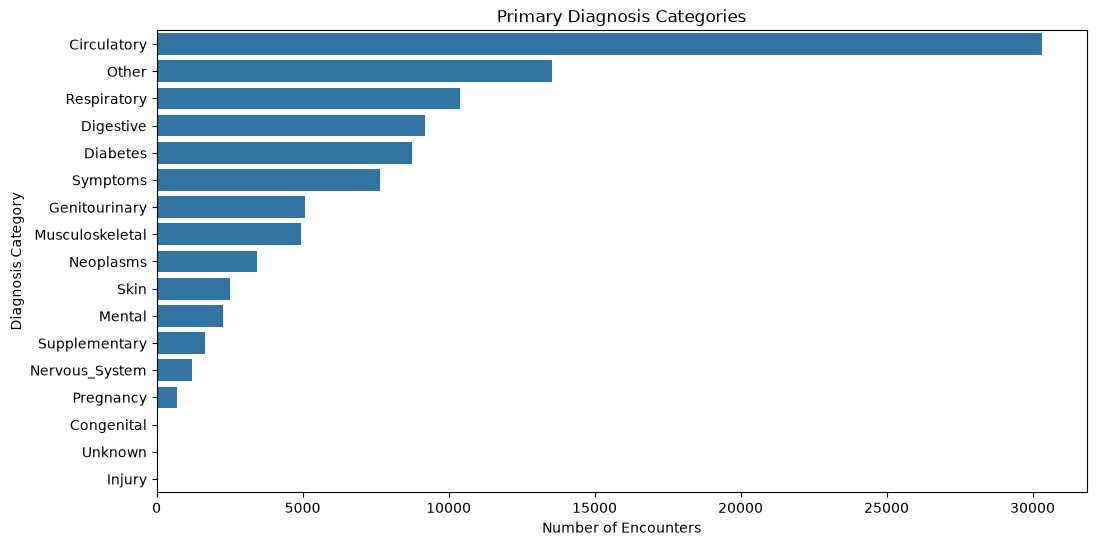

In [29]:
df["primary_diagnosis_category"] = (
    df["diag_1_category"]
)

df[
    "primary_diagnosis_category"
].value_counts()


plt.figure(
    figsize=(12, 6)
)

sns.countplot(
    data=df,
    y="primary_diagnosis_category",
    order=df[
        "primary_diagnosis_category"
    ].value_counts().index
)

plt.title(
    "Primary Diagnosis Categories"
)

plt.xlabel(
    "Number of Encounters"
)

plt.ylabel(
    "Diagnosis Category"
)

plt.show()

In [30]:
df["diagnosis_count"] = (
    df[
        [
            "diag_1_category",
            "diag_2_category",
            "diag_3_category"
        ]
    ]
    .ne("Unknown")
    .sum(axis=1)
)

df[
    "diagnosis_count"
].value_counts()

diagnosis_count
3    100244
2      1243
1       278
0         1
Name: count, dtype: int64

In [31]:
df["has_diabetes_diagnosis"] = (
    (
        df["diag_1_category"]
        == "Diabetes"
    )
    |
    (
        df["diag_2_category"]
        == "Diabetes"
    )
    |
    (
        df["diag_3_category"]
        == "Diabetes"
    )
).astype(int)


df[
    "has_diabetes_diagnosis"
].value_counts()

has_diabetes_diagnosis
0    63742
1    38024
Name: count, dtype: int64

In [32]:
engineered_features = [
    "total_previous_visits",
    "high_utilization_patient",
    "high_risk_utilization",
    "high_medication_burden",
    "diagnosis_count",
    "has_diabetes_diagnosis"
]


for feature in engineered_features:

    print(
        "\n" + "=" * 60
    )

    print(
        feature
    )

    print(
        df.groupby(
            feature
        )[
            "readmitted"
        ].mean()
        * 100
    )


total_previous_visits
total_previous_visits
0      36.187934
1      50.659445
2      58.030213
3      62.025745
4      64.985994
5      68.123772
6      72.505712
7      74.654378
8      75.631769
9      75.813953
10     78.148148
11     82.258065
12     86.029412
13     82.653061
14     81.609195
15     83.505155
16     86.764706
17     87.301587
18     87.500000
19    100.000000
20     86.956522
21     71.428571
22     86.666667
23    100.000000
24     55.555556
25    100.000000
26     50.000000
27     77.777778
28    100.000000
29    100.000000
30     50.000000
31     50.000000
32    100.000000
33    100.000000
34    100.000000
35     80.000000
36     80.000000
37     50.000000
38    100.000000
40    100.000000
41    100.000000
42    100.000000
48    100.000000
49    100.000000
61    100.000000
68    100.000000
80    100.000000
Name: readmitted, dtype: float64

high_utilization_patient
high_utilization_patient
0    42.110659
1    67.511767
Name: readmitted, dtype: float64

high_ris

In [33]:
FEATURED_DATA_PATH = (
    BASE_DIR
    / "Data"
    / "Processed"
    / "diabetic_data_feature_engineered.csv"
)


df.to_csv(
    FEATURED_DATA_PATH,
    index=False
)

print(
    "Feature-engineered dataset saved successfully."
)

print(
    FEATURED_DATA_PATH
)

Feature-engineered dataset saved successfully.
c:\Users\Sai\Documents\HealthSense_AI\Data\Processed\diabetic_data_feature_engineered.csv


In [34]:
demographic_features = [
    "race",
    "gender",
    "age"
]

hospital_features = [
    "time_in_hospital",
    "hospital_stay_category",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

utilization_features = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "total_previous_visits",
    "high_utilization_patient",
    "high_risk_utilization"
]

clinical_features = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses",
    "diagnosis_count",
    "high_medication_burden"
]

diabetes_features = [
    "diabetesMed",
    "insulin",
    "A1Cresult_available",
    "max_glu_serum_available",
    "has_diabetes_diagnosis"
]

diagnosis_features = [
    "primary_diagnosis_category",
    "diag_2_category",
    "diag_3_category"
]

In [35]:
feature_columns = (
    demographic_features
    + hospital_features
    + utilization_features
    + clinical_features
    + diabetes_features
    + diagnosis_features
)

print(
    "Total modeling features:",
    len(feature_columns)
)

print(
    feature_columns
)

Total modeling features: 28
['race', 'gender', 'age', 'time_in_hospital', 'hospital_stay_category', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'number_outpatient', 'number_emergency', 'number_inpatient', 'total_previous_visits', 'high_utilization_patient', 'high_risk_utilization', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'diagnosis_count', 'high_medication_burden', 'diabetesMed', 'insulin', 'A1Cresult_available', 'max_glu_serum_available', 'has_diabetes_diagnosis', 'primary_diagnosis_category', 'diag_2_category', 'diag_3_category']


In [36]:
X = df[
    feature_columns
].copy()

y = df[
    "readmitted"
].copy()

groups = df[
    "patient_nbr"
].copy()

In [37]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)



X_train = X.iloc[
    train_idx
]

X_test = X.iloc[
    test_idx
]

y_train = y.iloc[
    train_idx
]

y_test = y.iloc[
    test_idx
]

In [38]:
train_patients = set(
    groups.iloc[
        train_idx
    ]
)

test_patients = set(
    groups.iloc[
        test_idx
    ]
)

overlap = (
    train_patients
    .intersection(
        test_patients
    )
)

print(
    "Patients appearing in both train and test:",
    len(overlap)
)

Patients appearing in both train and test: 0


In [39]:
categorical_features = (
    X_train
    .select_dtypes(
        include=[
            "object",
            "category"
        ]
    )
    .columns
    .tolist()
)

numerical_features = (
    X_train
    .select_dtypes(
        exclude=[
            "object",
            "category"
        ]
    )
    .columns
    .tolist()
)

print(
    "Categorical features:"
)

print(
    categorical_features
)

print(
    "\nNumerical features:"
)

print(
    numerical_features
)

Categorical features:
['race', 'gender', 'age', 'hospital_stay_category', 'diabetesMed', 'insulin', 'primary_diagnosis_category', 'diag_2_category', 'diag_3_category']

Numerical features:
['time_in_hospital', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'number_outpatient', 'number_emergency', 'number_inpatient', 'total_previous_visits', 'high_utilization_patient', 'high_risk_utilization', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'diagnosis_count', 'high_medication_burden', 'A1Cresult_available', 'max_glu_serum_available', 'has_diabetes_diagnosis']


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import xgboost as xgb

In [41]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)



preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [42]:
xgb_improved = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            xgb.XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)



print(
    "Training improved XGBoost..."
)

xgb_improved.fit(
    X_train,
    y_train
)

print(
    "Training completed."
)

Training improved XGBoost...
Training completed.


In [43]:
y_pred_xgb_improved = (
    xgb_improved.predict(
        X_test
    )
)

y_prob_xgb_improved = (
    xgb_improved.predict_proba(
        X_test
    )[:, 1]
)

In [44]:
xgb_improved_metrics = {
    "Model": "XGBoost Improved",

    "Accuracy": accuracy_score(
        y_test,
        y_pred_xgb_improved
    ),

    "Precision": precision_score(
        y_test,
        y_pred_xgb_improved
    ),

    "Recall": recall_score(
        y_test,
        y_pred_xgb_improved
    ),

    "F1": f1_score(
        y_test,
        y_pred_xgb_improved
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_xgb_improved
    )
}

xgb_improved_metrics

{'Model': 'XGBoost Improved',
 'Accuracy': 0.649183744355679,
 'Precision': 0.6281749473423368,
 'Recall': 0.5547652916073968,
 'F1': 0.5891923300406741,
 'ROC_AUC': 0.7042281910679071}

In [45]:
baseline_xgb_metrics = {
    "Model": "XGBoost Baseline",
    "Accuracy": 0.645115,
    "Precision": 0.628542,
    "Recall": 0.531568,
    "F1": 0.576002,
    "ROC_AUC": 0.698612
}


comparison = pd.DataFrame(
    [
        baseline_xgb_metrics,
        xgb_improved_metrics
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost Baseline,0.645115,0.628542,0.531568,0.576002,0.698612
1,XGBoost Improved,0.649184,0.628175,0.554765,0.589192,0.704228


In [46]:
xgb_model = (
    xgb_improved
    .named_steps[
        "classifier"
    ]
)

preprocessor_fitted = (
    xgb_improved
    .named_steps[
        "preprocessor"
    ]
)


feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

print(
    "Total transformed features:",
    len(feature_names)
)

Total transformed features: 97


In [47]:
feature_importance = (
    xgb_model.feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df.head(20)

,Feature,Importance
8,num__high_utilization_patient,0.083098
7,num__total_previous_visits,0.068669
6,num__number_inpatient,0.051201
2,num__discharge_disposition_id,0.029889
57,cat__primary_diagnosis_category_Pregnancy,0.021951
9,num__high_risk_utilization,0.021122
41,cat__diabetesMed_No,0.017688
13,num__number_diagnoses,0.016757
42,cat__diabetesMed_Yes,0.016182
3,num__admission_source_id,0.015355


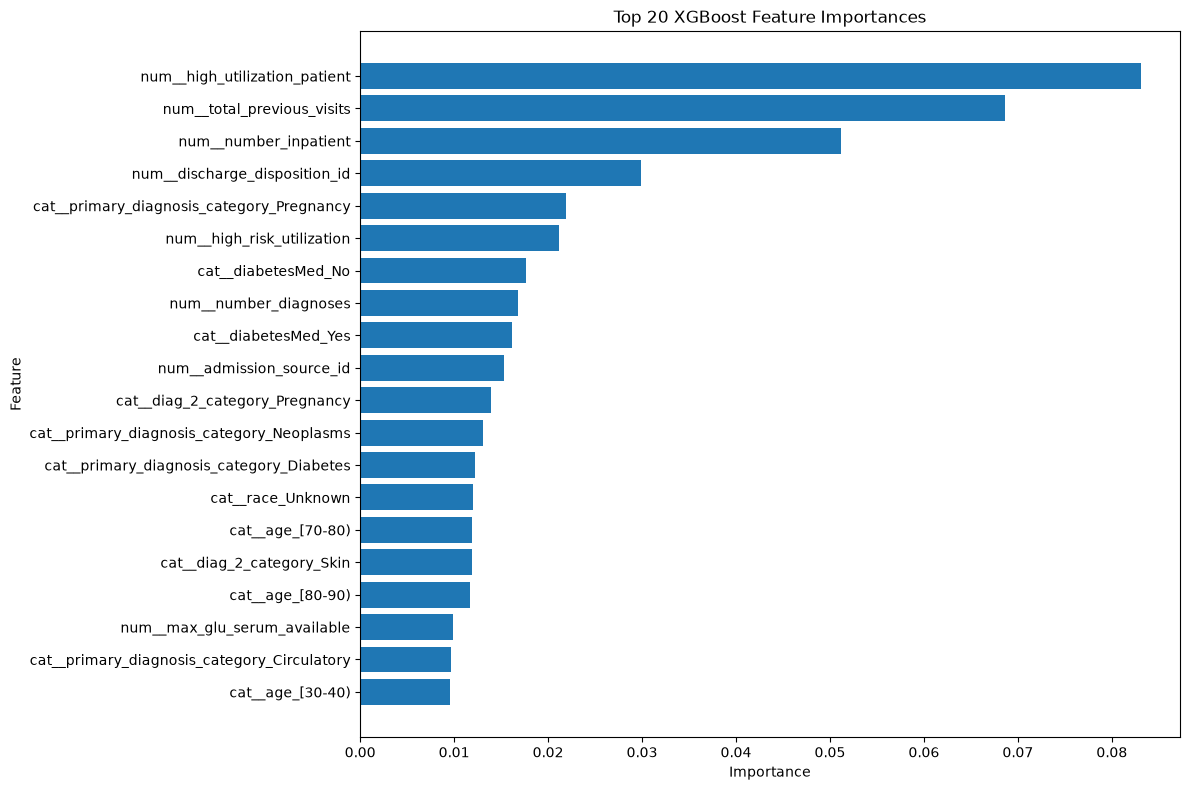

In [48]:
top_features = (
    importance_df
    .head(20)
    .sort_values(
        by="Importance"
    )
)

plt.figure(
    figsize=(12, 8)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 20 XGBoost Feature Importances"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

In [49]:
import shap

X_test_transformed = (
    preprocessor_fitted
    .transform(X_test)
)

print(
    "Original test shape:",
    X_test.shape
)

print(
    "Transformed test shape:",
    X_test_transformed.shape
)



Original test shape: (20153, 28)
Transformed test shape: (20153, 97)


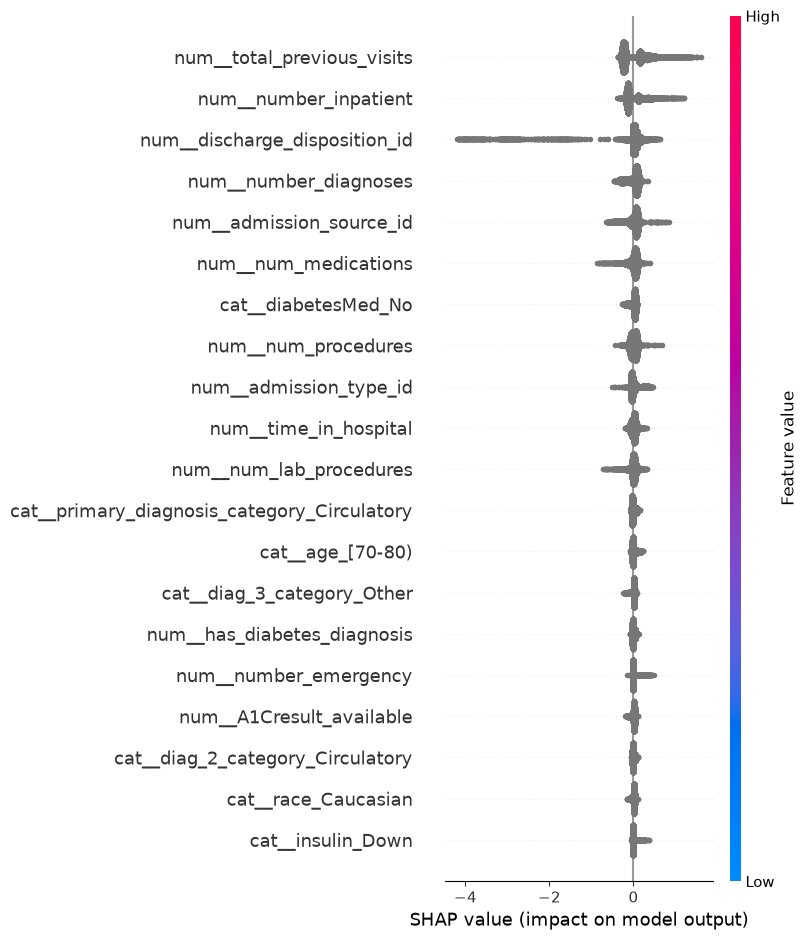

In [50]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer(
    X_test_transformed
)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=20
)

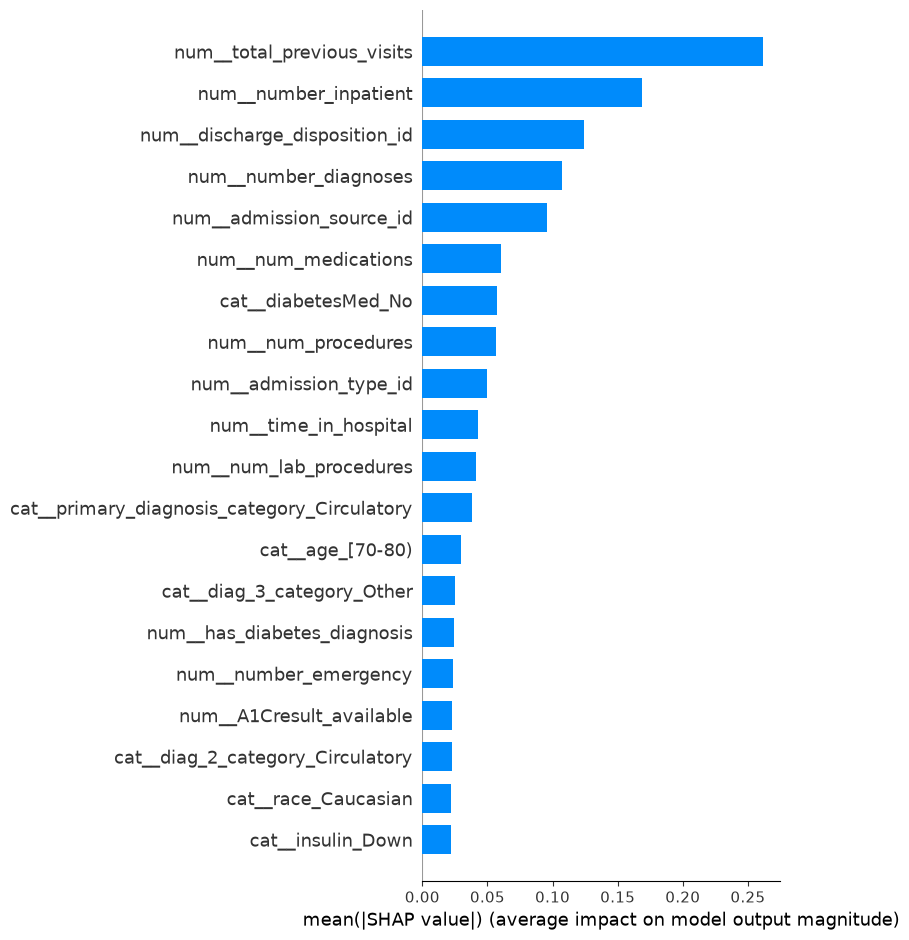

In [51]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

In [52]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

thresholds = np.arange(
    0.20,
    0.71,
    0.05
)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb_improved >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),

        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.500620,0.475598,0.986322,0.641749
1,0.25,0.529648,0.490505,0.960937,0.649484
2,0.30,0.560711,0.508671,0.917934,0.654598
3,0.35,0.590532,0.530058,0.855783,0.654641
4,0.40,0.622141,0.560563,0.771747,0.649418
5,0.45,0.642138,0.593881,0.666922,0.628286
6,0.50,0.649184,0.628175,0.554765,0.589192
7,0.55,0.648092,0.668422,0.444469,0.533912
8,0.60,0.638118,0.707602,0.344239,0.463158
9,0.65,0.619412,0.746064,0.243681,0.367371


In [53]:
best_f1_row = (
    threshold_df
    .loc[
        threshold_df["F1"].idxmax()
    ]
)

print(
    "Best threshold based on F1:"
)

print(
    best_f1_row
)

Best threshold based on F1:
Threshold    0.350000
Accuracy     0.590532
Precision    0.530058
Recall       0.855783
F1           0.654641
Name: 3, dtype: float64


In [54]:
recall_candidates = (
    threshold_df[
        threshold_df["Recall"] >= 0.60
    ]
)

if not recall_candidates.empty:

    best_recall_threshold = (
        recall_candidates
        .sort_values(
            by="Precision",
            ascending=False
        )
        .iloc[0]
    )

    print(
        "Best threshold with Recall >= 60%:"
    )

    print(
        best_recall_threshold
    )

else:

    print(
        "No tested threshold achieved Recall >= 60%."
    )

Best threshold with Recall >= 60%:
Threshold    0.450000
Accuracy     0.642138
Precision    0.593881
Recall       0.666922
F1           0.628286
Name: 5, dtype: float64


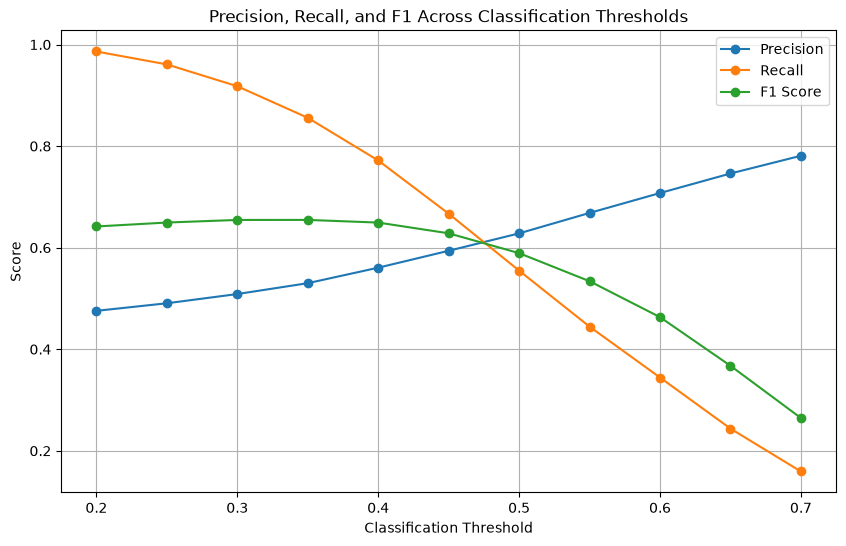

In [55]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Precision, Recall, and F1 Across Classification Thresholds"
)

plt.legend()

plt.grid(
    True
)

plt.show()

In [56]:
default_threshold = (
    threshold_df[
        np.isclose(
            threshold_df["Threshold"],
            0.50
        )
    ]
)

default_threshold


comparison_thresholds = pd.DataFrame(
    [
        {
            "Strategy": "Default Threshold",
            "Threshold": 0.50,
            "Accuracy": default_threshold[
                "Accuracy"
            ].iloc[0],
            "Precision": default_threshold[
                "Precision"
            ].iloc[0],
            "Recall": default_threshold[
                "Recall"
            ].iloc[0],
            "F1": default_threshold[
                "F1"
            ].iloc[0]
        },
        {
            "Strategy": "Best F1 Threshold",
            "Threshold": best_f1_row[
                "Threshold"
            ],
            "Accuracy": best_f1_row[
                "Accuracy"
            ],
            "Precision": best_f1_row[
                "Precision"
            ],
            "Recall": best_f1_row[
                "Recall"
            ],
            "F1": best_f1_row[
                "F1"
            ]
        }
    ]
)

comparison_thresholds

,Strategy,Threshold,Accuracy,Precision,Recall,F1
0,Default Threshold,0.50,0.649184,0.628175,0.554765,0.589192
1,Best F1 Threshold,0.35,0.590532,0.530058,0.855783,0.654641


In [57]:
optimal_threshold = (
    best_f1_row[
        "Threshold"
    ]
)

y_pred_final = (
    y_prob_xgb_improved
    >= optimal_threshold
).astype(int)



final_metrics = {
    "Model": "XGBoost Improved - Optimized Threshold",

    "Threshold": optimal_threshold,

    "Accuracy": accuracy_score(
        y_test,
        y_pred_final
    ),

    "Precision": precision_score(
        y_test,
        y_pred_final,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_pred_final,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        y_pred_final,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob_xgb_improved
    )
}

final_metrics

{'Model': 'XGBoost Improved - Optimized Threshold',
 'Threshold': np.float64(0.35),
 'Accuracy': 0.5905324269339552,
 'Precision': 0.5300576075906472,
 'Recall': 0.8557829084144873,
 'F1': 0.6546413325521051,
 'ROC_AUC': 0.7042281910679071}

In [58]:
from pathlib import Path
import joblib

In [59]:
BASE_DIR = Path.cwd().parent
MODEL_DIR = (
    BASE_DIR
    / "Models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = MODEL_DIR / "xgb_readmission_model.pkl"

print(MODEL_PATH)


joblib.dump(
    xgb_improved,
    MODEL_PATH
)

print("Model saved successfully!")



c:\Users\Sai\Documents\HealthSense_AI\Models\xgb_readmission_model.pkl
Model saved successfully!
